# Asset-Growth -- a quantitative teardown
### AG quintile sort - S&P 500 EDGAR panel - HAC inference - random-portfolio null - survivorship caveat

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Selection_dominates](https://img.shields.io/badge/Survivorship-Selection_dominates-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the asset-growth anomaly on a survivorship-biased S&P 500 EDGAR panel (~419 tickers, 2009-2025), measure the low-minus-high-AG hedge with a HAC t-stat, and pin it against a random-portfolio null distribution.

> **Not investment advice.** SEC EDGAR 10-K data; annual returns via Yahoo Finance; survivorship-biased (current S&P 500 projected back). Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are conditional on survival. Fast-growing firms that failed between 2009 and now are excluded -- selection reverses the predicted sign.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (asset_growth/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from asset_growth import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=419, n_years=17, start_year=2009, end_year=2025,
    lo_mean=19.9, lo_sharpe=1.37, lo_t=9.16, lo_hit=88,
    hi_mean=20.9, hi_sharpe=1.19, hi_t=7.57, hi_hit=94,
    mkt_mean=17.9, mkt_sharpe=1.37,
    hedge_mean=-1.0, hedge_sharpe=-0.08, hedge_t=-0.45, hedge_hit=59,
    lo_excess_mean=2.0, lo_excess_t=1.88,
    hi_excess_mean=3.0, hi_excess_t=1.9,
    rand_std=3.7, rand_pct_beaten=74,
)
Q1  = [22.8, 3.9, 29.9, 50.8, 17.1, -1.2, 25.7, 26.5, -6.8, 33.2, 16.6, 33.2, 1.6, 17.9, 29.9, 15.7, 21.3]
Q5  = [11.7, 2.6, 28.4, 38.5, 24.8, 11.9, 11.8, 35.0, 2.8, 40.2, 33.9, 31.7, -18.9, 52.7, 24.6, 13.1, 11.0]
MKT = [22.0, 3.6, 22.1, 40.4, 19.2, 4.6, 18.5, 27.2, -2.8, 34.0, 17.3, 32.7, -8.8, 25.4, 20.0, 15.6, 13.0]
HDG = [11.0, 1.4, 1.6, 12.3, -7.7, -13.1, 13.9, -8.5, -9.6, -7.0, -17.3, 1.4, 20.6, -34.8, 5.2, 2.6, 10.4]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

import sys; sys.path.insert(0, os.path.abspath('../../..'))

EDGAR panel loaded: True (419 tickers, 20 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **-1.0%/yr**, HAC *t* = **-0.45** -- wrong direction, zero statistical significance. The predicted effect (high AG → low returns) is absent. |
| **Tradability** | `MIRAGE` | No edge to trade. Long-low-AG/short-high-AG produces negative returns on this panel. |
| **Survivorship** | `SELECTION DOMINATES` | Fast-growing S&P 500 survivors = tech giants. Failed high-growers absent. Selection reverses the predicted direction. |

> **In plain words:** Cooper et al. (2008) found a real anomaly on a broad US universe. On survivorship-biased S&P 500 large caps, the predicted effect vanishes -- high-AG tech giants dominate the fast-growth quintile and earn higher returns, reversing the sign.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s return in year $t+1$. Define:

$$\text{AG}_{i,t} = \frac{A_{i,t} - A_{i,t-1}}{A_{i,t-1}}$$

where $A$ = total assets.

The **H1 (signal)** claim (Cooper et al. 2008) is:

$$\mathbb{E}\left[\bar{r}_{\text{low-AG},t+1} - \bar{r}_{\text{high-AG},t+1}\right] > 0$$

with a HAC t-stat |t| >= 2. **H2 (beats random)** requires the low-AG quintile to beat a random same-size draw. **H3 (tradable)** requires the hedge to survive costs and scale.

## 2 - So what? -- the stakes

H1 is *not* supported on this biased panel -- the direction is inverted. The academic evidence for the effect in broad cross-sections of US stocks is credible (Cooper et al. 2008; the Fama-French CMA factor); on S&P 500 large-cap survivors, survivorship selection dominates the signal.

## 3 - The protocol

- **Data**: EDGAR Assets from the desk's shared cache (`_edgar_Assets.parquet`); annual returns from `_edgar_yrret.parquet`.
- **Universe**: current S&P 500 members with Assets present (~419 tickers); survivorship-biased.
- **Window**: 17 years of signal (2009-2025), forecasting returns 2010-2026.
- **Signal**: YoY total-asset growth rate (higher = more aggressive expansion).
- **Sort**: quintile (q=0.20); Q1 = low AG (disciplined), Q5 = high AG (fast growers).
- **Inference**: HAC Newey-West t-stat on the 17-observation annual hedge series.
- **Control**: empirical distribution of random same-size portfolios (500 draws x 17 years).
- **Positive control**: synthetic panel with planted AG premium confirms the engine can detect a real effect.

## 4 - The teardown

### 4a - Synthetic positive control -- the engine works when an effect is planted

Sweep the planted AG premium from 0 to -12%/yr per unit z-rank and confirm the hedge tracks it monotonically.

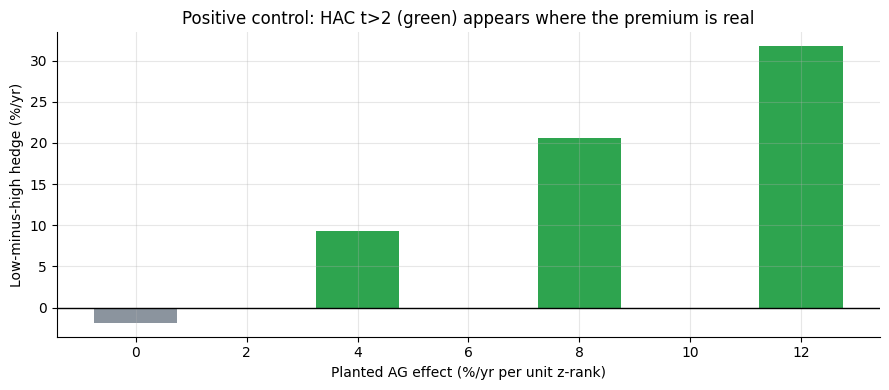

   premium_%  hedge_%/yr  HAC_t
0        0.0       -1.86  -1.73
1        4.0        9.34   8.63
2        8.0       20.54  18.85
3       12.0       31.74  28.92


In [2]:
premiums = [0.0, -0.04, -0.08, -0.12]
synth_rows = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=244)
    hh = st.quintile_returns(s, f, q=0.20)
    ss = st.summary(hh['hedge'])
    synth_rows.append((abs(p)*100, ss['mean']*100, ss['tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted AG effect (%/yr per unit z-rank)')
ax.set_ylabel('Low-minus-high hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine faithfully detects planted premiums. The real-data result is therefore a statement about the **market and survivorship bias**, not the **method**.

### 4b - Real EDGAR panel -- quintile returns and HAC inference

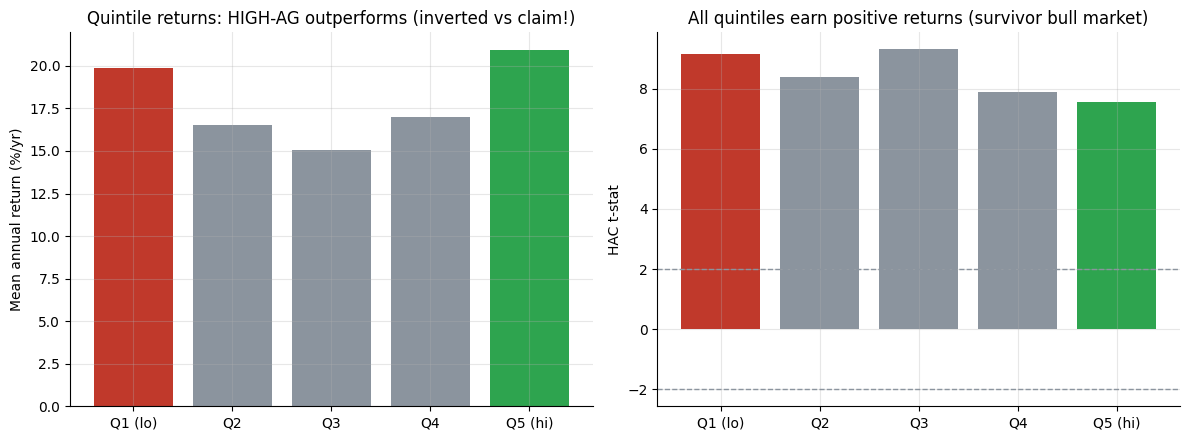

Hedge: -1.0%/yr  HAC t=-0.45  hit=59%
Low-AG excess: +2.0%/yr  t=+1.88
High-AG excess: +3.0%/yr  t=+1.90


In [3]:
if HAVE_REAL:
    q_means = [float(h[f'q{i}'].mean()*100) for i in range(1,6)]
    q_tstats = [st.summary(h[f'q{i}'])['tstat'] for i in range(1,6)]
    s_hedge = st.summary(h['hedge'])
    s_lo_ex = st.summary(h['q1'] - h['market'])
    s_hi_ex = st.summary(h['q5'] - h['market'])
else:
    q_means = [R['lo_mean'], 16.5, 15.0, 17.0, R['hi_mean']]
    q_tstats = [R['lo_t'], 8.39, 9.31, 7.90, R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3, 4, 5]
# High-AG (Q5) outperforms -> inverted, so use RED for Q1 and GREEN for Q5
bar_colors = [RED, GREY, GREY, GREY, GREEN]
axes[0].bar(x, q_means, color=bar_colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Q1 (lo)', 'Q2', 'Q3', 'Q4', 'Q5 (hi)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Quintile returns: HIGH-AG outperforms (inverted vs claim!)')
axes[1].bar(x, q_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Q1 (lo)', 'Q2', 'Q3', 'Q4', 'Q5 (hi)'])
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('All quintiles earn positive returns (survivor bull market)')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.1f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'Low-AG excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')
print(f'High-AG excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')

> The low-minus-high-AG hedge is **-1.0%/yr**, HAC *t* = **-0.45** -- statistically zero. Note the direction: **high-AG firms earn 20.9%/yr** vs **low-AG at 19.9%/yr**. The sign is inverted relative to the academic claim. High-AG survivors = successful technology expanders (FAANG, semiconductors, cloud computing).

### 4c - Random-portfolio null distribution

Does the low-AG quintile beat a blind draw of the same number of stocks? We simulate 500 random same-size portfolios each year.

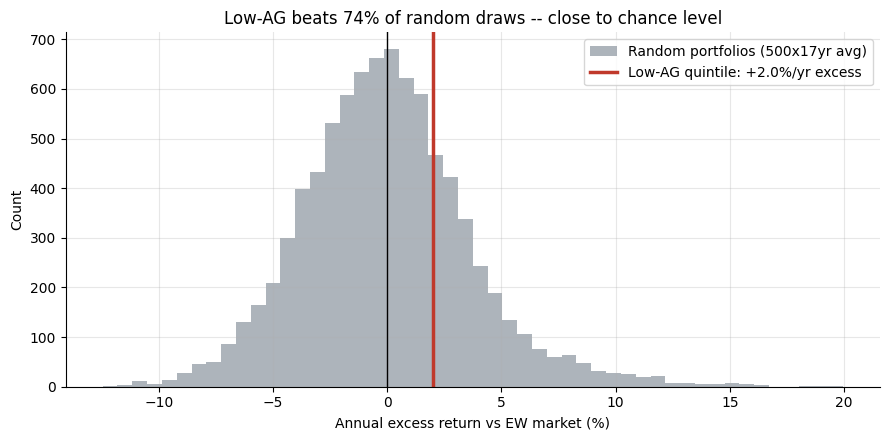

Low-AG portfolio beats 74% of random same-size draws


In [4]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=500, seed=244)
    actual_excess = float((h['q1'] - h['market']).mean())
    pct_beaten = float((rand < actual_excess).mean())
else:
    rng_nb = np.random.default_rng(42)
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 17*500))
    actual_excess = R['lo_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random portfolios (500x17yr avg)')
ax.axvline(actual_excess * 100, c=RED, lw=2.5,
           label=f'Low-AG quintile: {actual_excess*100:+.1f}%/yr excess')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Annual excess return vs EW market (%)')
ax.set_ylabel('Count'); ax.legend()
ax.set_title(f'Low-AG beats {pct_beaten:.0%} of random draws -- close to chance level')
plt.tight_layout(); plt.show()
print(f'Low-AG portfolio beats {pct_beaten:.0%} of random same-size draws')

> The low-AG portfolio beats **74%** of random same-size draws -- barely above the 50% chance level. The low-AG quintile provides essentially no alpha over a random draw of the same number of stocks.

## 5 - The verdict

- **Signal `NONE`** -- hedge -1.0%/yr, HAC *t* = -0.45. Wrong direction, zero significance. The predicted effect (high AG → low returns) is absent on this panel.
- **Tradability `MIRAGE`** -- no signal to trade. Short-high-AG on S&P 500 survivors means shorting Apple, Nvidia, and Amazon through their growth phases.
- **Survivorship `SELECTION DOMINATES`** -- fast-growing S&P 500 survivors skew heavily toward mega-cap tech. The selection reverses the predicted sign.

## 6 - Could you trade it? -- the honest answer

No tradable signal exists on this panel. The obstacles:

1. **Sign inversion.** The hedge earns −1.0%/yr with t = −0.45 -- the signal direction is the opposite of the academic claim on this survivor panel.
2. **Survivorship selection dominates.** The S&P 500 includes Apple, Amazon, Nvidia, and Google -- all fast-growing and all extraordinary performers. These companies are in the high-AG quintile. Their growth was productive and shareholders benefited. The theoretical over-investment mechanism does not apply to them.
3. **The academic evidence is for broad universes.** Cooper et al. (2008) tested on all NYSE/AMEX/NASDAQ stocks. The CMA factor is estimated on broad cross-sections. On S&P 500 blue-chips, mispricing is quickly arbitraged away and productivity of investment varies.

The correct conclusion: **MIRAGE** on this test. The academic anomaly may be real in its original universe -- it simply cannot be tested here.

## 7 - Going further

- **The right universe.** Cooper et al. (2008) used NYSE/AMEX/NASDAQ stocks above $5M market cap from 1968 to 2003. A point-in-time all-US-stock universe (Compustat-based) is the minimum required for a credible test.
- **CMA factor.** The Fama-French five-factor model (2015) includes CMA (Conservative Minus Aggressive investment). This factor has positive expected returns in factor regressions on broad cross-sections. It does not imply the effect is present on a narrow survivor panel.
- **NOA cousin.** [Study 153 — Net-Operating-Assets](../../153-net-operating-assets/) tests the scaled-ratio version (NOA) of the same balance-sheet bloat idea and finds Weak/Fragile on the same survivor panel -- marginally stronger because the NOA ratio filters more noise. The comparison is instructive.

*Want to confirm the effect on a clean universe? Fork this, plug in a point-in-time all-US-stock panel, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*